In [1]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
 
n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
n_features = X.shape[1]
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]
 
print("Total dataset size:")
print("n_samples:", n_samples)
print("n_features:", n_features)
print("n_classes:", n_classes)

c:\Users\kelse\OneDrive - The University of Queensland\Desktop\gitCourse\.venv\Lib\site-packages\sklearn\datasets\_base.py:1522: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976006
  warnings.warn(f"Retry downloading from url: {remote.url}")


Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
 
n_components = 150

In [5]:
mean = np.mean(X_train, axis=0)
X_train -= mean
X_test -= mean
 
U, S, V = np.linalg.svd(X_train, full_matrices=False)
components = V[:n_components]
eigenfaces = components.reshape((n_components, h, w))
 
X_transformed = np.dot(X_train, components.T)
print(X_transformed.shape)
X_test_transformed = np.dot(X_test, components.T)
print(X_test_transformed.shape)

(966, 150)
(322, 150)


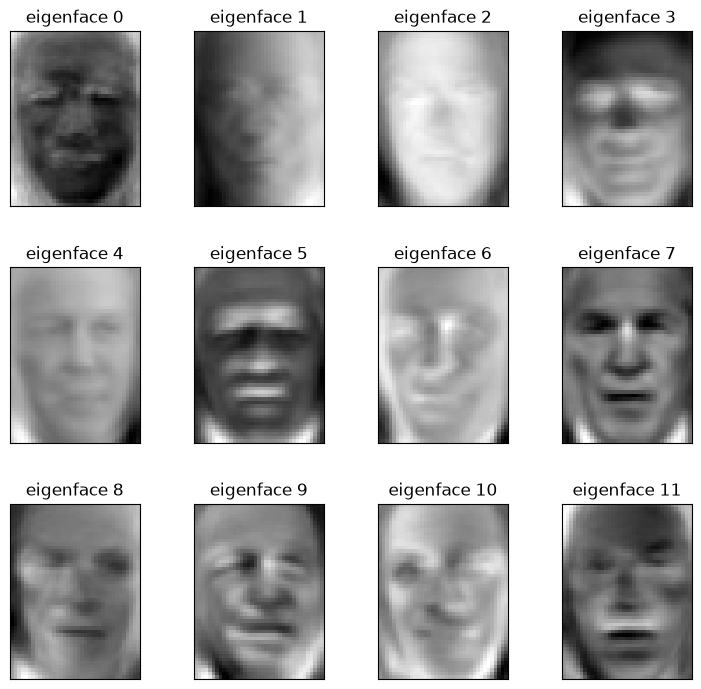

In [6]:
import matplotlib.pyplot as plt

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    plt.figure(figsize=(1.8*n_col, 2.4*n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i+1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())
 
eigenface_titles = [f"eigenface {i}" for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)

plt.show()

(966,)


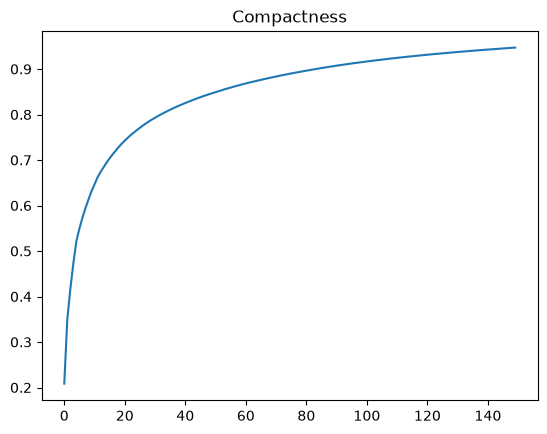

In [7]:
explained_variance = (S**2) / (n_samples - 1)
total_var = explained_variance.sum()
explained_variance_ratio = explained_variance / total_var
ratio_cumsum = np.cumsum(explained_variance_ratio)
print(ratio_cumsum.shape)
eigenvalueCount = np.arange(n_components)

plt.plot(eigenvalueCount, ratio_cumsum[:n_components])
plt.title('Compactness')
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

estimator = RandomForestClassifier(n_estimators=150, max_depth=15, max_features=150)
estimator.fit(X_transformed, y_train)
 
predictions = estimator.predict(X_test_transformed)
correct = predictions == y_test
total_test = len(X_test_transformed)

print("Total Testing:", total_test)
print("Predictions:", predictions)
print("Which correct:", correct)
print("Total Correct:", np.sum(correct))
print("Accuracy:", np.sum(correct) / total_test)
print(classification_report(y_test, predictions, target_names=target_names))

Total Testing: 322
Predictions: [3 3 4 3 3 3 3 1 3 3 3 6 3 3 3 3 6 3 3 4 1 1 3 3 1 1 3 3 3 3 3 3 3 3 3 3 3
 3 3 1 3 1 3 1 1 3 3 3 4 3 3 3 3 3 1 2 1 3 5 3 6 1 3 4 3 5 1 4 1 3 6 6 3 3
 3 2 3 1 3 3 6 3 3 3 3 3 3 3 3 3 5 6 3 1 1 3 1 1 1 6 3 3 3 3 3 3 3 3 3 1 3
 1 3 3 3 3 3 4 1 3 1 3 3 1 3 4 5 3 1 3 6 6 6 3 3 4 3 3 1 1 3 3 3 1 3 3 1 3
 3 1 1 3 3 3 3 3 6 3 3 3 4 6 5 1 3 3 5 1 3 3 3 3 3 1 5 3 3 3 3 5 3 3 3 1 2
 3 3 3 3 2 4 3 3 3 6 3 3 3 3 3 3 3 3 3 5 1 4 2 4 3 1 5 4 3 3 3 3 1 3 3 3 5
 3 1 1 3 3 3 1 3 3 3 3 3 3 1 6 3 3 3 3 4 2 3 4 3 3 3 3 4 4 2 3 4 3 4 3 1 3
 3 3 3 3 1 3 6 6 1 6 1 1 1 3 3 6 3 3 3 3 3 1 1 3 3 3 1 3 3 3 4 3 3 5 3 3 1
 3 5 3 3 3 6 6 3 1 3 3 3 1 3 3 3 1 3 3 3 3 3 3 3 4 3]
Which correct: [ True  True False  True  True  True False  True  True  True  True False
  True False  True  True False  True  True  True  True False  True False
 False  True False  True  True  True False  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False False  True
 False 

c:\Users\kelse\OneDrive - The University of Queensland\Desktop\gitCourse\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kelse\OneDrive - The University of Queensland\Desktop\gitCourse\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kelse\OneDrive - The University of Queensland\Desktop\gitCourse\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

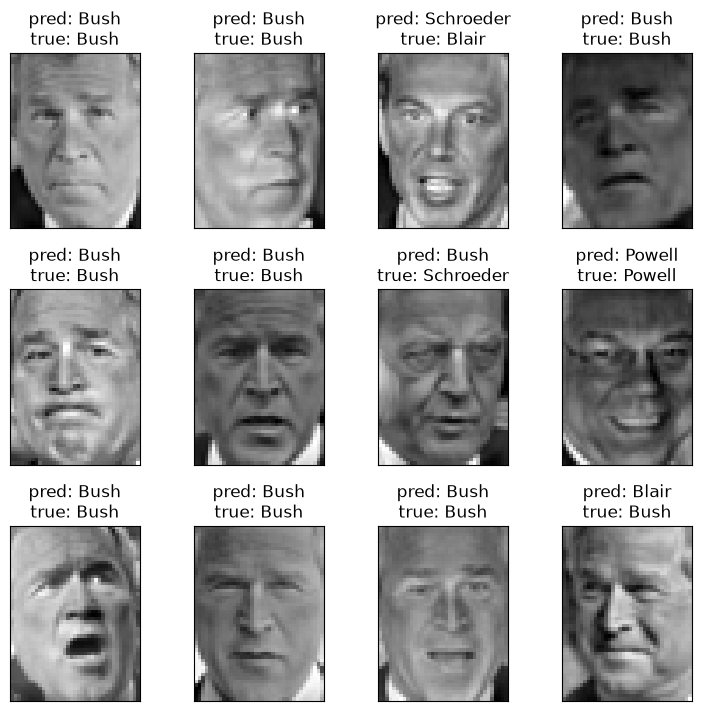

In [12]:
# ---------------------------------------------------------------------------
# DIAGRAM 3 - Sample predictions gallery (correct vs incorrect)
# ---------------------------------------------------------------------------
def title_prediction(y_pred, y_true, target_names, i):
    pred_name = target_names[y_pred[i]].rsplit(' ', 1)[-1]
    true_name = target_names[y_true[i]].rsplit(' ', 1)[-1]
    return f"pred: {pred_name}\ntrue: {true_name}"
 
prediction_titles = [title_prediction(predictions, y_test, target_names, i) for i in range(12)]
plot_gallery(X_test, prediction_titles, h, w)

In [17]:
# ---------------------------------------------------------------------------
# STEP 2.2 - PyTorch equivalent classifier (dense NN on top of the same PCA features)
# ---------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_t = torch.tensor(X_transformed, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_transformed, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)
 
class FaceClassifier(nn.Module):
    def __init__(self, n_components, n_classes):
        super().__init__()
        self.fc1 = nn.Linear(n_components, 128)
        self.fc2 = nn.Linear(128, n_classes)
 
    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)
 
model = FaceClassifier(n_components, n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
 
n_epochs = 150
losses, test_accs = [], []
 
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
 
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1)
        acc = (preds == y_test_t).float().mean().item()
        test_accs.append(acc)
 
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.4f}, test_acc={acc:.4f}")
 
final_nn_accuracy = test_accs[-1]
print(f"\nFinal PyTorch classifier accuracy: {final_nn_accuracy:.4f}")
print(f"Random Forest accuracy: {np.sum(correct) / total_test:.4f}")

Epoch 0: loss=1.9500, test_acc=0.1304
Epoch 20: loss=1.5728, test_acc=0.5373
Epoch 40: loss=1.2208, test_acc=0.5994
Epoch 60: loss=0.8869, test_acc=0.6801
Epoch 80: loss=0.5937, test_acc=0.7795
Epoch 100: loss=0.3798, test_acc=0.8137
Epoch 120: loss=0.2454, test_acc=0.8323
Epoch 140: loss=0.1651, test_acc=0.8385

Final PyTorch classifier accuracy: 0.8385
Random Forest accuracy: 0.6304


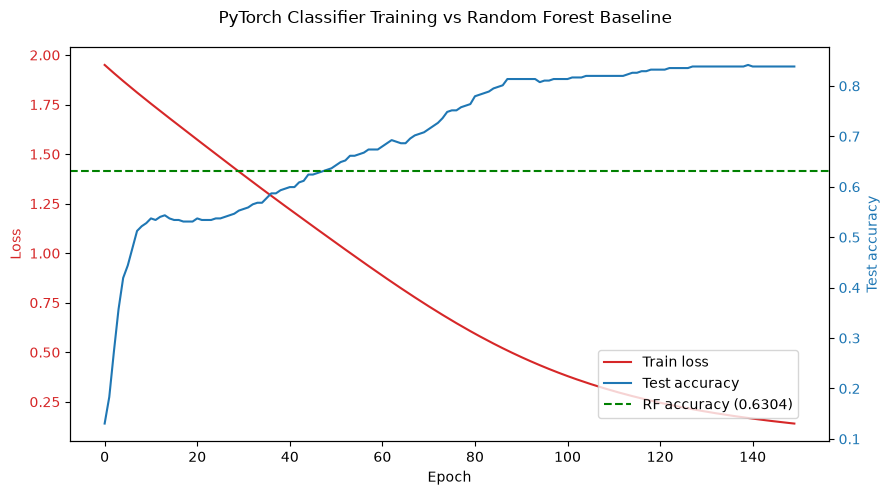

Saved: part2_pytorch_training_curve.png


In [21]:
# ---------------------------------------------------------------------------
# DIAGRAM 4 - PyTorch training curve (loss + accuracy)
# ---------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(losses, color='tab:red', label='Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
 
ax2 = ax1.twinx()
ax2.plot(test_accs, color='tab:blue', label='Test accuracy')
ax2.set_ylabel('Test accuracy', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.axhline(np.sum(correct)/total_test, color='green', linestyle='--', label=f'RF accuracy ({np.sum(correct) / total_test:.4f})')
 
fig.suptitle('PyTorch Classifier Training vs Random Forest Baseline')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.savefig('part2_pytorch_training_curve.png', dpi=150)
plt.show()
print("Saved: part2_pytorch_training_curve.png")